In [1]:
import os
import h5py
import time
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from pandas import DataFrame
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os
import h5py
import time
import matplotlib
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
from pandas import DataFrame
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from deap import algorithms, base, creator, tools
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, TimeDistributed
from keras.models import Sequential
from keras.layers import Dense, Conv1D
from keras.layers import Dropout, Input
from keras import initializers
from keras.layers import MaxPooling1D
from keras.models import Model
from keras.layers import TimeDistributed, Flatten
from keras.layers import Dense, Activation, Dropout
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
%matplotlib inline

In [2]:
filename = 'N-CMAPSS_DS05.h5'

In [3]:
# Time tracking, Operation time (min):  0.003
t = time.process_time()  

# Load data
with h5py.File(filename, 'r') as hdf:
        # Development set
        W_dev = np.array(hdf.get('W_dev'))             # W
        X_s_dev = np.array(hdf.get('X_s_dev'))         # X_s
        X_v_dev = np.array(hdf.get('X_v_dev'))         # X_v
        T_dev = np.array(hdf.get('T_dev'))             # T
        Y_dev = np.array(hdf.get('Y_dev'))             # RUL  
        A_dev = np.array(hdf.get('A_dev'))             # Auxiliary

        # Test set
        W_test = np.array(hdf.get('W_test'))           # W
        X_s_test = np.array(hdf.get('X_s_test'))       # X_s
        X_v_test = np.array(hdf.get('X_v_test'))       # X_v
        T_test = np.array(hdf.get('T_test'))           # T
        Y_test = np.array(hdf.get('Y_test'))           # RUL  
        A_test = np.array(hdf.get('A_test'))           # Auxiliary
        
        # Varnams
        W_var = np.array(hdf.get('W_var'))
        X_s_var = np.array(hdf.get('X_s_var'))  
        X_v_var = np.array(hdf.get('X_v_var')) 
        T_var = np.array(hdf.get('T_var'))
        A_var = np.array(hdf.get('A_var'))
        
        # from np.array to list dtype U4/U5
        W_var = list(np.array(W_var, dtype='U20'))
        X_s_var = list(np.array(X_s_var, dtype='U20'))  
        X_v_var = list(np.array(X_v_var, dtype='U20')) 
        T_var = list(np.array(T_var, dtype='U20'))
        A_var = list(np.array(A_var, dtype='U20'))
                          
W = np.concatenate((W_dev, W_test), axis=0)  
X_s = np.concatenate((X_s_dev, X_s_test), axis=0)
X_v = np.concatenate((X_v_dev, X_v_test), axis=0)
T = np.concatenate((T_dev, T_test), axis=0)
Y = np.concatenate((Y_dev, Y_test), axis=0) 
A = np.concatenate((A_dev, A_test), axis=0) 
    
print('')
print("Operation time (min): " , (time.process_time()-t)/60)
print('')
print ("W shape: " + str(W.shape))
print ("X_s shape: " + str(X_s.shape))
print ("X_v shape: " + str(X_v.shape))
print ("Y shape: " + str(Y.shape))
print ("T shape: " + str(T.shape))
print ("A shape: " + str(A.shape))


Operation time (min):  0.012760416666666666

W shape: (6912652, 4)
X_s shape: (6912652, 14)
X_v shape: (6912652, 14)
Y shape: (6912652, 1)
T shape: (6912652, 10)
A shape: (6912652, 4)


In [4]:
W = np.concatenate((W_dev, W_test), axis=0)  
X_s = np.concatenate((X_s_dev, X_s_test), axis=0)
Y = np.concatenate((Y_dev, Y_test), axis=0)
A = np.concatenate((A_dev, A_test), axis=0) 

X = np.concatenate((W, X_s, A, Y), axis=1)
Y=  np.concatenate((A, Y), axis=1)
Y = DataFrame(data=Y, columns=A_var+['Y'])
X = DataFrame(data=X, columns=W_var+X_s_var+A_var+['Y'])

In [5]:
Y.describe()

,unit,cycle,Fc,hs,Y
count,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06
mean,5.239374e+00,4.002810e+01,2.226115e+00,2.958030e-01,3.900481e+01
std,2.904136e+00,2.368351e+01,8.078304e-01,4.564029e-01,2.376696e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,2.000000e+01,2.000000e+00,0.000000e+00,1.900000e+01
50%,6.000000e+00,3.900000e+01,2.000000e+00,0.000000e+00,3.800000e+01
75%,8.000000e+00,5.900000e+01,3.000000e+00,1.000000e+00,5.800000e+01
max,1.000000e+01,1.000000e+02,3.000000e+00,1.000000e+00,9.900000e+01


In [6]:
Y.drop("cycle",axis=1,inplace=True)
Y.drop("Fc",axis=1,inplace=True)
Y.drop("hs",axis=1,inplace=True)
Y.describe()

,unit,Y
count,6.912652e+06,6.912652e+06
mean,5.239374e+00,3.900481e+01
std,2.904136e+00,2.376696e+01
min,1.000000e+00,0.000000e+00
25%,2.000000e+00,1.900000e+01
50%,6.000000e+00,3.800000e+01
75%,8.000000e+00,5.800000e+01
max,1.000000e+01,9.900000e+01


In [7]:
X.drop("cycle",axis=1,inplace=True)
X.drop("Fc",axis=1,inplace=True)
X.drop("hs",axis=1,inplace=True)
X.drop("alt",axis=1,inplace=True)
X.describe()

,Mach,TRA,T2,T24,T30,T48,T50,P15,P2,P21,P24,Ps30,P40,P50,Nf,Nc,Wf,unit,Y
count,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06
mean,5.319760e-01,5.996256e+01,4.909356e+02,5.699286e+02,1.334474e+03,1.638378e+03,1.129818e+03,1.304474e+01,1.019378e+01,1.324339e+01,1.606218e+01,2.379398e+02,2.422144e+02,1.019697e+01,1.953364e+03,8.248141e+03,2.548930e+00,5.239374e+00,3.900481e+01
std,1.208898e-01,1.834395e+01,1.985279e+01,2.112542e+01,6.869315e+01,1.239105e+02,6.251462e+01,2.883393e+00,2.421477e+00,2.927303e+00,3.450926e+00,5.919650e+01,6.003612e+01,2.758136e+00,1.873247e+02,2.277543e+02,7.877672e-01,2.904136e+00,2.376696e+01
min,3.150000e-04,2.355452e+01,4.369255e+02,4.998511e+02,1.091806e+03,1.095354e+03,7.923581e+02,6.700688e+00,5.285918e+00,6.802729e+00,8.186232e+00,9.248497e+01,9.466065e+01,4.635623e+00,1.471000e+03,7.429764e+03,5.963687e-01,1.000000e+00,0.000000e+00
25%,4.393620e-01,4.631803e+01,4.741667e+02,5.546204e+02,1.287931e+03,1.552724e+03,1.085702e+03,1.049740e+01,7.972020e+00,1.065726e+01,1.319101e+01,1.929589e+02,1.965787e+02,7.665725e+00,1.835894e+03,8.094517e+03,1.980253e+00,2.000000e+00,1.900000e+01
50%,5.371380e-01,6.257768e+01,4.960515e+02,5.678197e+02,1.329839e+03,1.647608e+03,1.120127e+03,1.338949e+01,1.060965e+01,1.359339e+01,1.617596e+01,2.256779e+02,2.301263e+02,1.051082e+01,1.997333e+03,8.237001e+03,2.340848e+00,6.000000e+00,3.800000e+01
75%,6.330240e-01,7.664008e+01,5.072438e+02,5.838195e+02,1.373982e+03,1.711727e+03,1.165307e+03,1.528072e+01,1.209400e+01,1.551342e+01,1.847904e+01,2.724938e+02,2.773639e+02,1.232305e+01,2.112084e+03,8.383625e+03,2.948869e+00,8.000000e+00,5.800000e+01
max,7.492590e-01,8.876890e+01,5.343834e+02,6.341967e+02,1.540888e+03,1.993206e+03,1.356282e+03,2.044899e+01,1.568410e+01,2.076040e+01,2.643985e+01,4.485121e+02,4.553945e+02,1.672457e+01,2.285550e+03,8.921408e+03,5.607345e+00,1.000000e+01,9.900000e+01


In [8]:
df_A = DataFrame(data=A, columns=A_var)
df_A.describe()

,unit,cycle,Fc,hs
count,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06
mean,5.239374e+00,4.002810e+01,2.226115e+00,2.958030e-01
std,2.904136e+00,2.368351e+01,8.078304e-01,4.564029e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,2.000000e+00,2.000000e+01,2.000000e+00,0.000000e+00
50%,6.000000e+00,3.900000e+01,2.000000e+00,0.000000e+00
75%,8.000000e+00,5.900000e+01,3.000000e+00,1.000000e+00
max,1.000000e+01,1.000000e+02,3.000000e+00,1.000000e+00


In [9]:
print('Engine units in df: ', np.unique(X['unit']))
print('Engine units in df: ', np.unique(Y['unit']))


Engine units in df:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Engine units in df:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


In [10]:
X_train= X.loc[(X.unit == 1) | (X.unit == 3) | (X.unit == 5) | (X.unit == 6) | (X.unit == 7) | (X.unit == 9) | (X.unit == 10) ]
Y_train=Y.loc[(Y.unit == 1) | (Y.unit == 3) | (Y.unit == 5) |  (Y.unit == 6) | (Y.unit == 7) | (Y.unit == 9) | (Y.unit == 10) ]
X_test=X.loc[(X.unit == 2) | (X.unit == 4) | (X.unit == 8) ]
Y_test=Y.loc[(Y.unit == 2) | (Y.unit == 4) | (Y.unit == 8) ]

In [11]:
print('Engine units in df: ', np.unique(X_train['unit']))
print('Engine units in df: ', np.unique(Y_train['unit']))
print('Engine units in df: ', np.unique(X_test['unit']))
print('Engine units in df: ', np.unique(Y_test['unit']))
print("X_train size is ",X_train.shape)
print("X_test size is ",X_test.shape)
print("y_train size is ",Y_train.shape)
print("y_test size is ",Y_test.shape)


Engine units in df:  [ 1.  3.  5.  6.  7.  9. 10.]
Engine units in df:  [ 1.  3.  5.  6.  7.  9. 10.]
Engine units in df:  [2. 4. 8.]
Engine units in df:  [2. 4. 8.]
X_train size is  (4900033, 19)
X_test size is  (2012619, 19)
y_train size is  (4900033, 2)
y_test size is  (2012619, 2)


In [12]:
X_train.drop("unit",axis=1,inplace=True)
X_test.drop("unit",axis=1,inplace=True)
X_train.drop("Y",axis=1,inplace=True)
X_test.drop("Y",axis=1,inplace=True)
Y_train.drop("unit",axis=1,inplace=True)
Y_test.drop("unit",axis=1,inplace=True)
print("X_train size is ",X_train.shape)
print("X_test size is ",X_test.shape)
print("y_train size is ",Y_train.shape)
print("y_test size is ",Y_test.shape)

C:\Users\Pc\AppData\Local\Temp\ipykernel_11260\816249269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop("unit",axis=1,inplace=True)
C:\Users\Pc\AppData\Local\Temp\ipykernel_11260\816249269.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop("unit",axis=1,inplace=True)
C:\Users\Pc\AppData\Local\Temp\ipykernel_11260\816249269.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop("Y",axis=1,inplace

X_train size is  (4900033, 17)
X_test size is  (2012619, 17)
y_train size is  (4900033, 1)
y_test size is  (2012619, 1)


C:\Users\Pc\AppData\Local\Temp\ipykernel_11260\816249269.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop("Y",axis=1,inplace=True)
C:\Users\Pc\AppData\Local\Temp\ipykernel_11260\816249269.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_train.drop("unit",axis=1,inplace=True)
C:\Users\Pc\AppData\Local\Temp\ipykernel_11260\816249269.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_test.drop("unit",axis=1,inplace=

In [13]:
def reshape_time_series(data, sequence_length):
    """
    Reshapes time series data for CNN input.

    Parameters:
    data (np.array): The time series dataset, expected to be a 2D array.
    sequence_length (int): The length of the input sequences for the CNN.

    Returns:
    np.array: Reshaped dataset suitable for CNN input.
    """
    X = []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])

    return np.array(X)


In [14]:
X_train = reshape_time_series(X_train,20)
X_test = reshape_time_series(X_test,20)
Y_train = reshape_time_series(Y_train,20)
Y_test = reshape_time_series(Y_test,20)

In [15]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D
from keras.layers import LSTM
from keras.layers import Dense, Dropout, Flatten

In [16]:
print("X_train size is ",X_train.shape)
print("X_test size is ",X_test.shape)
print("y_train size is ",Y_train.shape)
print("y_test size is ",Y_test.shape)

X_train size is  (4900013, 20, 17)
X_test size is  (2012599, 20, 17)
y_train size is  (4900013, 20, 1)
y_test size is  (2012599, 20, 1)


In [17]:
from sklearn.model_selection import train_test_split

def split_dataset(X, y, train_size=0.8):
    """
    Splits the dataset into training and validation sets.

    Parameters:
    X (np.array): Features of the dataset.
    y (np.array): Labels or targets of the dataset.
    train_size (float): Proportion of the dataset to include in the training set.

    Returns:
    X_train, X_val, y_train, y_val: Split dataset into training and validation sets.
    """
    X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=train_size, random_state=42)
    return X_train, X_val, y_train, y_val

In [18]:
X_train, X_val, Y_train, Y_val = split_dataset(X_train, Y_train, train_size=0.8)


In [19]:
print("X_train shape:", X_train.shape)
print("y_train shape:", Y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", Y_val.shape)

X_train shape: (3920010, 20, 17)
y_train shape: (3920010, 20, 1)
X_val shape: (980003, 20, 17)
y_val shape: (980003, 20, 1)


In [20]:
def reshape_labels_for_regression(y_data):
    """
    Reshapes the labels for a regression task.

    Parameters:
    y_data (np.array): Original labels with shape (number_of_samples, 20, 10).

    Returns:
    np.array: Reshaped labels with shape (number_of_samples, 1).
    """
    # Assuming we want to predict the first value at the last time step of each sequence
    # Adjust the index '0' if a different value is desired
    y_reshaped = y_data[:, -1, 0]  # Select the last time step, first value
    return y_reshaped.reshape(-1, 1)

In [21]:
import kerastuner as kt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Conv1D, MaxPooling1D, Flatten, Dropout, Concatenate, Masking
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import GroupShuffleSplit
import copy
import os
from tensorflow.keras.models import load_model

C:\Users\Pc\AppData\Local\Temp\ipykernel_11260\1420853871.py:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


Epoch 1/20
122501/122501 [==============================] - 471s 4ms/step - loss: 206.0643 - val_loss: 304.5682
Epoch 2/20
122501/122501 [==============================] - 458s 4ms/step - loss: 205.0729 - val_loss: 275.6979
Epoch 3/20
122501/122501 [==============================] - 458s 4ms/step - loss: 203.2443 - val_loss: 247.7968
Epoch 4/20
122501/122501 [==============================] - 475s 4ms/step - loss: 202.6058 - val_loss: 184.6079
Epoch 5/20
122501/122501 [==============================] - 484s 4ms/step - loss: 200.7217 - val_loss: 224.1842
Epoch 6/20
122501/122501 [==============================] - 455s 4ms/step - loss: 199.8407 - val_loss: 177.0044
Epoch 7/20
122501/122501 [==============================] - 461s 4ms/step - loss: 199.0897 - val_loss: 288.2771
Epoch 8/20
122501/122501 [==============================] - 457s 4ms/step - loss: 197.8913 - val_loss: 157.0285
Epoch 9/20
122501/122501 [==============================] - 456s 4ms/step - loss: 197.2712 - val_loss: 1

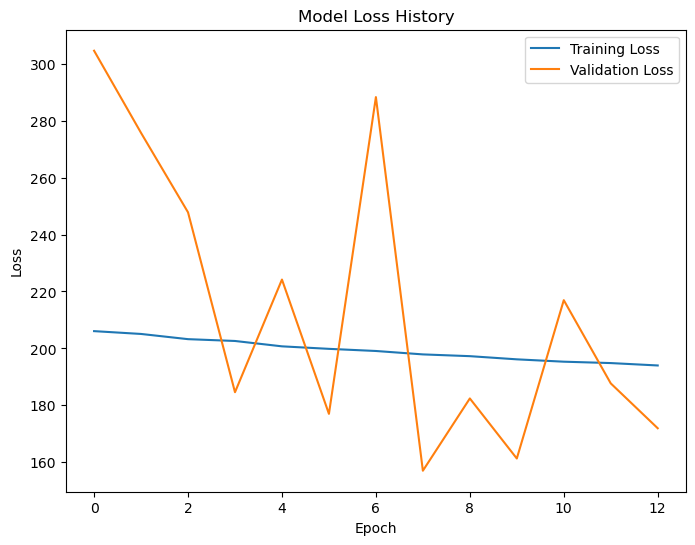

In [27]:
import keras_tuner as kt
from keras.models import Model, load_model
from keras.layers import Input, Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout, Masking, Concatenate
from keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import os

# Load the best model saved during tuning
best_model = load_model('best_model_during_tuning.h5')

from keras.callbacks import EarlyStopping

# Define early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Re-train the model (if needed)
history = best_model.fit(
    [X_train, X_train], Y_train,
    validation_data=([X_val, X_val], Y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

# Plot loss history
def plot_loss(history):
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss History')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.savefig('loss_plot.png')
    plt.show()

plot_loss(history)

In [23]:
print("Y_test shape:", Y_test.shape)
print("Predictions shape:", predictions.shape)

Y_test shape: (2012599, 20, 1)
Predictions shape: (2012599, 1)


In [29]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Predict on test data
predictions = best_model.predict([X_test, X_test])  # Or X_test if your model uses one input

# Extract the last timestep from Y_test
Y_test_last = Y_test[:, -1, 0]  # Shape: (2012599,)

# Flatten predictions
preds = predictions.reshape(-1)  # Shape: (2012599,)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(Y_test_last, preds))
print(f"Test RMSE after retraining: {rmse}")

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

In [25]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Extract last timestep from Y_test
Y_test_last = Y_test[:, -1, 0]  # Shape: (2012599,)

# Flatten predictions
preds = predictions.reshape(-1)  # Shape: (2012599,)

# Double-check lengths match
print("Y_test_last shape:", Y_test_last.shape)
print("predictions shape:", preds.shape)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(Y_test_last, preds))
print(f"Test RMSE: {rmse}")


Y_test_last shape: (2012599,)
predictions shape: (2012599,)
Test RMSE: 14.23429551561264
